# Lecture 6 — Linear Regression

**Credits**:

This notebook is modified from the materials provided with [Python Data Science Handbook](http://shop.oreilly.com/product/0636920034919.do) by Jake VanderPlas.

---

Linear regression models are a good starting point for regression tasks.
Such models are popular because they can be fit very quickly, and are very interpretable.
You are probably familiar with the simplest form of a linear regression model (i.e., fitting a straight line to data) but such models can be extended to model more complicated data behavior.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Simple Linear Regression

We will start with the most familiar linear regression, a straight-line fit to data.
A straight-line fit is a model of the form
$$
y = ax + b
$$
where $a$ is commonly known as the *slope*, and $b$ is commonly known as the *intercept*.

Consider the following data, which is scattered about a line with a slope of 2 and an intercept of -5:

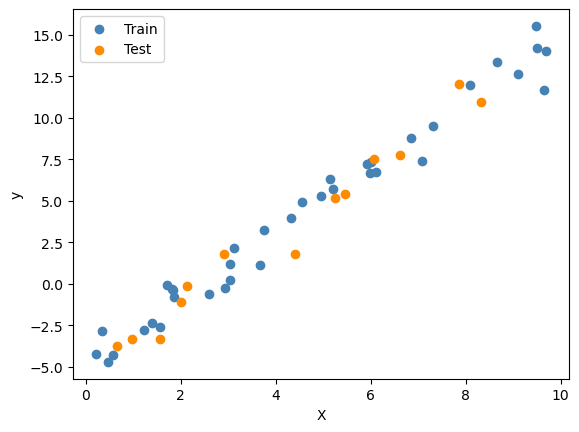

In [2]:
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(42)
X = 10 * rng.rand(50)
y = 2 * X - 5 + rng.randn(50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Scatter plot with train and test points in different colors
plt.scatter(X_train, y_train, color='steelblue', label='Train')
plt.scatter(X_test, y_test, color='darkorange', label='Test')
plt.legend()
plt.xlabel('X')
plt.ylabel('y');


We can use Scikit-Learn's ``LinearRegression`` estimator to fit this data and construct the best-fit line:

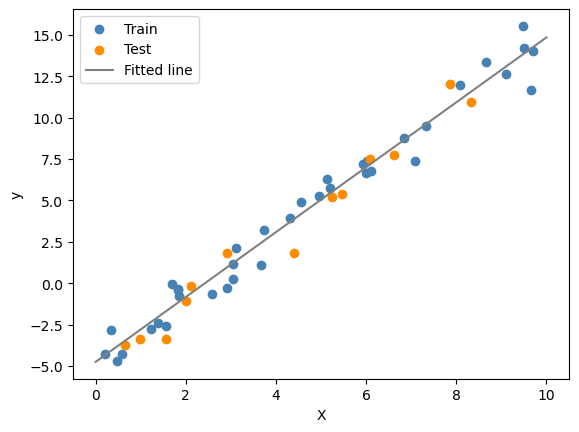

In [3]:
# Import the LinearRegression class from scikit-learn
from sklearn.linear_model import LinearRegression

# Instantiate the model
model = LinearRegression()

# Fit the model to the data
# sklearn expects X as a 2D array of shape (n_samples, n_features),
# so reshape(-1, 1) converts the 1D array x into a column vector
model.fit(X_train.reshape(-1, 1), y_train)

# Create 1000 evenly spaced values between 0 and 10 for plotting the regression line
xfit = np.linspace(0, 10, 1000)

# Predict y values for xfit; reshape to 2D as required by sklearn
yfit = model.predict(xfit.reshape(-1, 1))

plt.scatter(X_train, y_train, color='steelblue', label='Train')
plt.scatter(X_test, y_test, color='darkorange', label='Test')
plt.plot(xfit, yfit, color='gray', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.legend();

The slope and intercept of the data are contained in the model's fit parameters, which in Scikit-Learn are always marked by a trailing underscore.
Here the relevant parameters are ``coef_`` and ``intercept_``:

In [4]:
print("Model slope:    ", model.coef_[0])
print("Model intercept:", model.intercept_)

Model slope:     1.9601883068425603
Model intercept: -4.752522960211893


We see that the results are very close to the inputs, as we might hope.

In [5]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_train_pred = model.predict(X_train.reshape(-1, 1))
y_test_pred = model.predict(X_test.reshape(-1, 1))

print(f"{'Metric':<8} {'Train':>8} {'Test':>8}")
print("-" * 26)
for name, func in [("R²", r2_score), ("MAE", mean_absolute_error), ("MSE", mean_squared_error)]:
    train_val = func(y_train, y_train_pred)
    test_val = func(y_test, y_test_pred)
    print(f"{name:<8} {train_val:>8.4f} {test_val:>8.4f}")

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(f"{'RMSE':<8} {train_rmse:>8.4f} {test_rmse:>8.4f}")

Metric      Train     Test
--------------------------
R²         0.9764   0.9676
MAE        0.7287   0.7526
MSE        0.8127   0.8827
RMSE       0.9015   0.9395


When train and test metrics are close, the model generalizes well. A large gap (train performing much better than test) would signal overfitting. With simple linear regression on one feature this gap will be small usually in any case though.

The ``LinearRegression`` estimator is much more capable than this, however—in addition to simple straight-line fits, it can also handle multidimensional linear models of the form
$$
y = a_0 + a_1 x_1 + a_2 x_2 + \cdots
$$
where there are multiple $x$ values.
Geometrically, this is akin to fitting a plane to points in three dimensions, or fitting a hyper-plane to points in higher dimensions.

The multidimensional nature of such regressions makes them more difficult to visualize though.